In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv('/content/Titanic-Dataset.csv')

In [48]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
df.shape

(891, 12)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [51]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df = df.drop_duplicates()

In [54]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [55]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [56]:
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [57]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [58]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [59]:
print("Mean:")
print(df[['Age', 'Fare']].mean())

print("\nMedian:")
print(df[['Age', 'Fare']].median())

print("\nMode:")
print(df[['Age', 'Fare']].mode().iloc[0])

Mean:
Age     29.361582
Fare    32.204208
dtype: float64

Median:
Age     28.0000
Fare    14.4542
dtype: float64

Mode:
Age     28.00
Fare     8.05
Name: 0, dtype: float64


In [60]:
print("Variance:")
print(df[['Age', 'Fare']].var())

print("\nStandard Deviation:")
print(df[['Age', 'Fare']].std())

Variance:
Age      169.512498
Fare    2469.436846
dtype: float64

Standard Deviation:
Age     13.019697
Fare    49.693429
dtype: float64


In [61]:
Q1 = df[['Age', 'Fare']].quantile(0.25)
Q3 = df[['Age', 'Fare']].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:")
print(lower_bound)

print("\nUpper Bound:")
print(upper_bound)

Lower Bound:
Age      2.500
Fare   -26.724
dtype: float64

Upper Bound:
Age     54.5000
Fare    65.6344
dtype: float64


In [62]:
outliers = ((df[['Age', 'Fare']] < lower_bound) |
            (df[['Age', 'Fare']] > upper_bound))

print("Outliers in Age:", outliers['Age'].sum())
print("Outliers in Fare:", outliers['Fare'].sum())

Outliers in Age: 66
Outliers in Fare: 116


In [63]:
df['Age'] = df['Age'].clip(lower=lower_bound['Age'],
                           upper=upper_bound['Age'])

df['Fare'] = df['Fare'].clip(lower=lower_bound['Fare'],
                             upper=upper_bound['Fare'])

In [64]:
# Passengers above 50 years
older_passengers = df[df['Age'] > 50]

# Female passengers
female_passengers = df[df['Sex'] == 'female']

# First-class passengers
first_class = df[df['Pclass'] == 1]

print("Passengers above 50:", len(older_passengers))
print("Female passengers:", len(female_passengers))
print("First-class passengers:", len(first_class))

Passengers above 50: 64
Female passengers: 314
First-class passengers: 216


In [65]:
sorted_passengers = df.sort_values(by='Fare', ascending=False)

sorted_passengers[['Name', 'Pclass', 'Age', 'Fare', 'Survived']].head(10)

,Name,Pclass,Age,Fare,Survived
879,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",1,54.5,65.6344,1
369,"Aubart, Mme. Leontine Pauline",1,24.0,65.6344,1
366,"Warren, Mrs. Frank Manley (Anna Sophia Atkinson)",1,54.5,65.6344,1
373,"Ringhini, Mr. Sante",1,22.0,65.6344,0
835,"Compton, Miss. Sara Rebecca",1,39.0,65.6344,1
438,"Fortune, Mr. Mark",1,54.5,65.6344,0
435,"Carter, Miss. Lucile Polk",1,14.0,65.6344,1
846,"Sage, Mr. Douglas Bullen",3,28.0,65.6344,0
52,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",1,49.0,65.6344,1
829,"Stone, Mrs. George Nelson (Martha Evelyn)",1,54.5,65.6344,1


In [66]:
survival_by_gender = df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean'])

print(survival_by_gender)

        count  sum      mean
Sex                         
female    314  233  0.742038
male      577  109  0.188908


In [67]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [68]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [69]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [70]:
df.duplicated().sum()

np.int64(0)

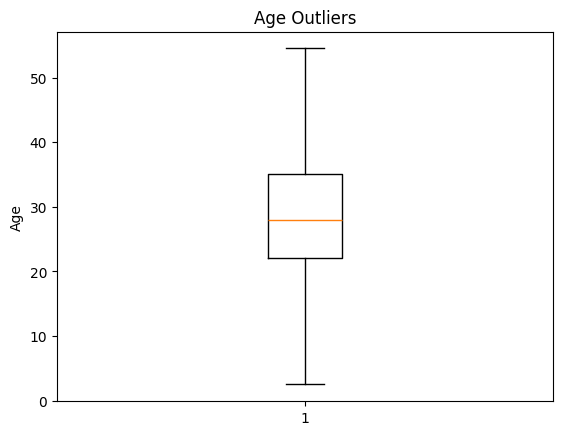

In [71]:
import matplotlib.pyplot as plt

plt.boxplot(df['Age'].dropna())
plt.title('Age Outliers')
plt.ylabel('Age')
plt.show()

In [72]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df['Age'] >= lower_limit) & (df['Age'] <= upper_limit)]

In [73]:
df.shape

(891, 12)

In [74]:
df[df['Age'] > 30]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,54.5,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,Unknown,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,54.5,0,1,11767,65.6344,C50,C
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,Unknown,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Unknown,Q


In [75]:
df[df['Sex'] == 'female']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Unknown,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,Unknown,C
...,...,...,...,...,...,...,...,...,...,...,...,...
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,Unknown,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,Unknown,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Unknown,Q
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [76]:
df[df['Pclass'] == 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,54.5,0,0,113783,26.5500,C103,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,54.5,0,1,11767,65.6344,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [77]:
df[(df['Sex'] == 'female') & (df['Pclass'] == 1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,54.5,0,0,113783,26.5500,C103,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,28.0,1,0,PC 17569,65.6344,B78,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,65.6344,D33,C
...,...,...,...,...,...,...,...,...,...,...,...,...
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,65.6344,Unknown,S
862,863,1,1,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48.0,0,0,17466,25.9292,D17,S
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,54.5,0,1,11767,65.6344,C50,C


In [78]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [79]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [80]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [81]:
df['Survived'].count()

np.int64(891)

In [82]:
df['Survived'].sum()

np.int64(342)

In [83]:
(df['Survived'] == 0).sum()

np.int64(549)

In [84]:
df['Survived'].mean() * 100

np.float64(38.38383838383838)

In [85]:
df.groupby('Sex')['Survived'].sum()

,Survived
Sex,
female,233
male,109


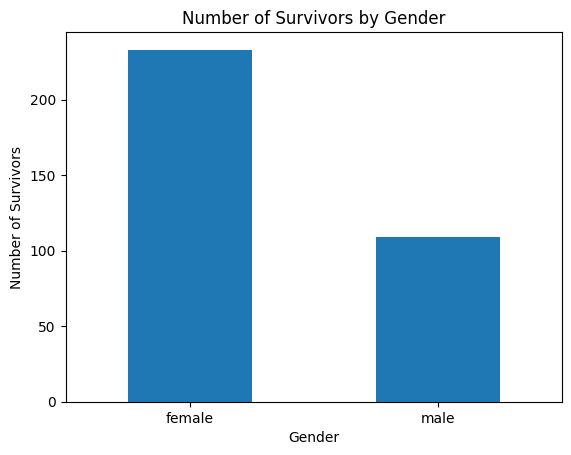

In [86]:
df.groupby('Sex')['Survived'].sum().plot(kind='bar')

plt.title('Number of Survivors by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Survivors')
plt.xticks(rotation=0)
plt.show()

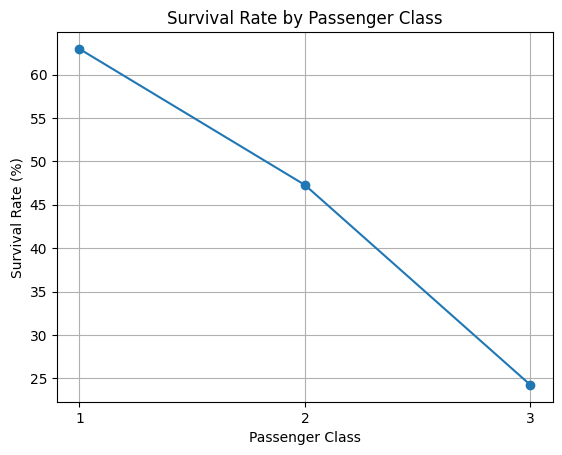

In [87]:
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100

plt.plot(survival_by_class.index, survival_by_class.values, marker='o')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks([1, 2, 3])
plt.grid()
plt.show()

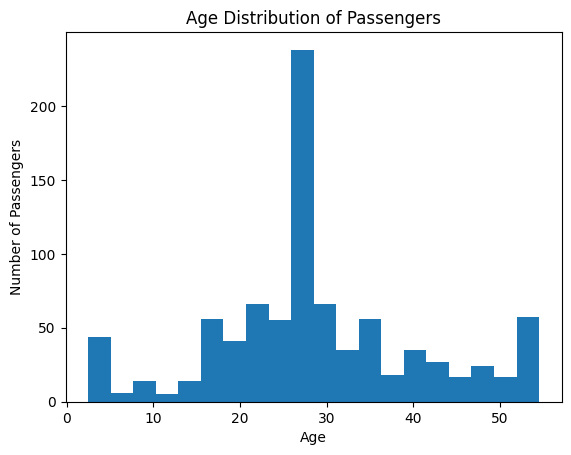

In [88]:
plt.hist(df['Age'], bins=20)

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

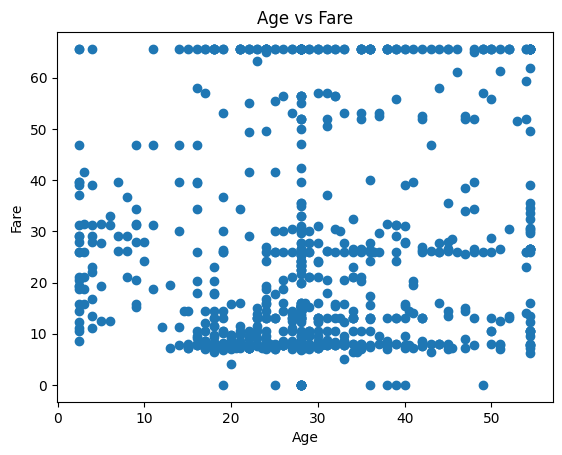

In [89]:
plt.scatter(df['Age'], df['Fare'])

plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

## EDA Summary

- The Titanic dataset was cleaned by handling missing values and checking for duplicate records.
- Missing values in the Age column were handled using the median, while missing values in the Embarked column were handled using the mode.
- No duplicate records were found in the dataset.
- Outliers in the Age column were identified using the IQR method and treated.
- Female passengers had a higher survival rate compared to male passengers.
- Passengers from 1st class had a higher survival rate compared to passengers from 2nd and 3rd class.
- Passenger age distribution showed that most passengers were in the younger and middle-age groups.
- The analysis showed differences in survival based on gender and passenger class.
- The scatter plot helped visualize the relationship between passenger age and fare.

## Conclusion

The Titanic dataset analysis shows that survival was strongly associated with passenger gender and class. Female passengers and passengers belonging to higher classes had better chances of survival. Data cleaning, filtering, grouping, statistical analysis, and visualization helped identify important survival trends in the dataset.